In [1]:
# ================================
# 📦 Step 1: Imports & Setup
# ================================
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, jaccard_score)

import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Conv2DTranspose, 
                                     concatenate, Input, Add, BatchNormalization, Activation)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ⚙️ Config
IMAGE_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 25

2026-04-18 16:50:10.931533: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776531011.139071      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776531011.204223      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# ================================
# 📦 Step 2: Dataset Paths
# ================================
train_image_path = "/kaggle/input/landslide-divided/dataset/train/images"
train_mask_path = "/kaggle/input/landslide-divided/dataset/train/masks"
val_image_path = "/kaggle/input/landslide-divided/dataset/validation/images"
val_mask_path = "/kaggle/input/landslide-divided/dataset/validation/masks"
test_image_path = "/kaggle/input/landslide-divided/dataset/test/images"
test_mask_path = "/kaggle/input/landslide-divided/dataset/test/masks"


In [3]:
# ================================
# 📦 Step 3: Preprocessing Functions
# ================================
def read_image(path):
    image = cv2.imread(path, cv2.IMREAD_COLOR)
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    image = image / 255.0
    return image

def read_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))
    mask = np.expand_dims(mask, axis=-1)
    mask = mask / 255.0
    return mask


In [5]:
# ================================
# 📦 Step 4: Data Generator
# ================================
class DataGenerator(Sequence):
    def __init__(self, image_paths, mask_paths, batch_size=BATCH_SIZE, shuffle=True):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def on_epoch_end(self):
        self.indices = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_images = [read_image(self.image_paths[i]) for i in indices]
        batch_masks = [read_mask(self.mask_paths[i]) for i in indices]
        return np.array(batch_images), np.array(batch_masks)

In [6]:
# Step 5: Deep Deconv Residual U-Net Model
def conv_block(x, filters):
    x_skip = x
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    if x_skip.shape[-1] != filters:
        x_skip = Conv2D(filters, 1, padding='same')(x_skip)
    x = Add()([x, x_skip])
    x = Activation('relu')(x)
    return x
def encoder_block(x, filters):
    x = conv_block(x, filters)
    p = MaxPooling2D((2, 2))(x)
    return x, p
def decoder_block(x, skip, filters):
    x = Conv2DTranspose(filters, (2, 2), strides=(2, 2), padding='same')(x)
    x = concatenate([x, skip])
    x = conv_block(x, filters)
    return x
def build_ddrunet(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)):
    inputs = Input(shape=input_shape)
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)
    b1 = conv_block(p4, 1024)
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    outputs = Conv2D(1, (1, 1), padding='same', activation='sigmoid')(d4)
    return Model(inputs, outputs)

In [7]:
# ================================
# 📦 Step 6: Load Dataset
# ================================
train_images = sorted(glob(os.path.join(train_image_path, "*.*")))
train_masks = sorted(glob(os.path.join(train_mask_path, "*.*")))
val_images = sorted(glob(os.path.join(val_image_path, "*.*")))
val_masks = sorted(glob(os.path.join(val_mask_path, "*.*")))

train_gen = DataGenerator(train_images, train_masks)
val_gen = DataGenerator(val_images, val_masks)

In [8]:
# ================================
# 📦 Step 7: Compile & Train
# ================================
model = build_ddrunet()
model.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("model.keras", save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
]

history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, callbacks=callbacks)


I0000 00:00:1776531143.502105      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776531143.504768      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1776531166.011343     102 service.cc:148] XLA service 0x7a0ac40037a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776531166.012289     102 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776531166.012320     102 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776531168.047225     102 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-04-18 16:52:52.897696: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng12{k11=0} for conv (f32[8,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_s

173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.8964 - loss: 0.2303
Epoch 1: val_loss improved from inf to 0.23573, saving model to model.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 181s 617ms/step - accuracy: 0.8966 - loss: 0.2297 - val_accuracy: 0.9491 - val_loss: 0.2357 - learning_rate: 1.0000e-04
Epoch 2/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.9507 - loss: 0.0866
Epoch 2: val_loss improved from 0.23573 to 0.18780, saving model to model.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 111s 643ms/step - accuracy: 0.9507 - loss: 0.0866 - val_accuracy: 0.9491 - val_loss: 0.1878 - learning_rate: 1.0000e-04
Epoch 3/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.9535 - loss: 0.0810
Epoch 3: val_loss improved from 0.18780 to 0.11409, saving model to model.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 117s 678ms/step - accuracy: 0.9535 - loss: 0.0810 - val_accuracy: 0.9505 - val_loss: 0.1141 - learning_rate: 1.0000e-04
Epoch 4/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy

In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │        256 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │      8,320 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128,  │          0 │ batch_normalizat

 Total params: 97,329,669 (371.28 MB)

 Trainable params: 32,439,297 (123.75 MB)

 Non-trainable params: 11,776 (46.00 KB)

 Optimizer params: 64,878,596 (247.49 MB)

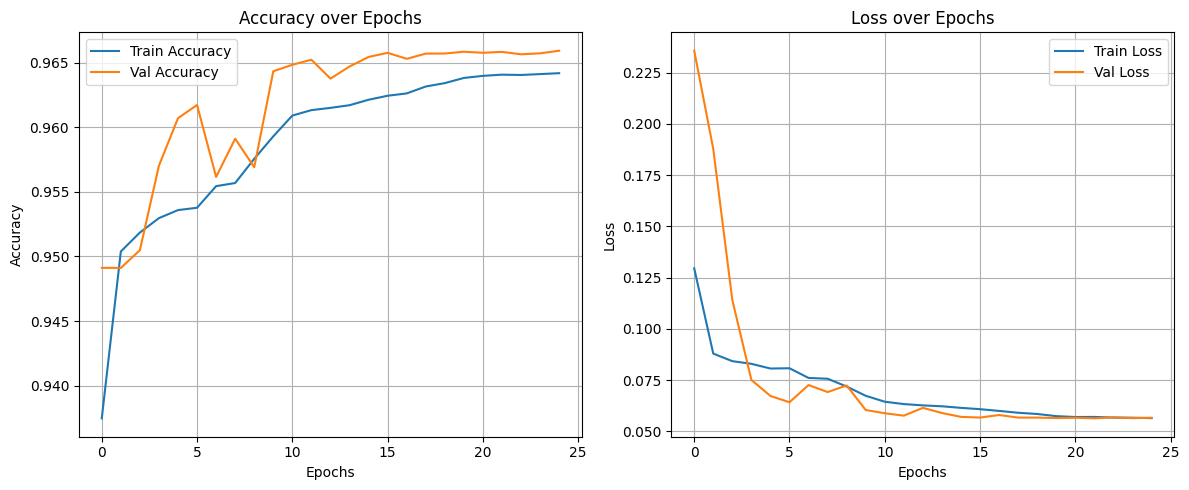

In [10]:
# ================================
# 📊 Step 8: Training Graphs
# ================================
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()
plt.grid()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


In [11]:
# ================================
# 📊 Step 9: Training & Testing Results
# ================================
test_images = sorted(glob(os.path.join(test_image_path, "*.png")))
test_masks = sorted(glob(os.path.join(test_mask_path, "*.png")))
test_gen = DataGenerator(test_images, test_masks, shuffle=False)

# Evaluate
train_loss, train_acc = model.evaluate(train_gen, verbose=0)
test_loss, test_acc = model.evaluate(test_gen, verbose=0)

print(f"✅ Final Training Accuracy: {train_acc*100:.2f}%")
print(f"✅ Final Testing Accuracy : {test_acc*100:.2f}%")


✅ Final Training Accuracy: 96.49%
✅ Final Testing Accuracy : 95.86%


In [12]:
# ================================
# 📊 Step 10: Classification Metrics
# ================================
y_true, y_pred = [], []

for i in range(len(test_gen)):
    X_batch, Y_batch = test_gen[i]
    preds = model.predict(X_batch)
    preds = (preds > 0.5).astype(np.uint8).flatten()
    Y_batch = (Y_batch > 0.5).astype(np.uint8).flatten()
    y_pred.extend(preds)
    y_true.extend(Y_batch)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=["No Landslide", "Landslide"]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step

📊 Classification Report:
              precision    recall  f1-sco

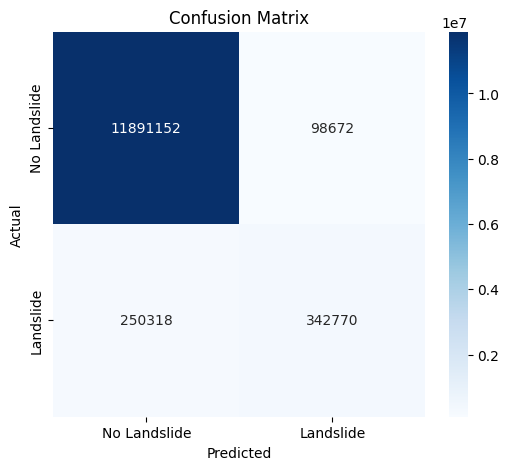

In [13]:
# ================================
# 📊 Step 11: Confusion Matrix
# ================================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Landslide", "Landslide"],
            yticklabels=["No Landslide", "Landslide"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [14]:
# ================================
# 📊 Step 12: Additional Metrics
# ================================
def dice_coef(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
iou = jaccard_score(y_true, y_pred)
dice = dice_coef(y_true, y_pred)

print("\n📈 Pixel-wise Evaluation Metrics:")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"IoU Score       : {iou:.4f}")
print(f"Dice Coefficient: {dice:.4f}")



📈 Pixel-wise Evaluation Metrics:
Accuracy        : 0.9723
Precision       : 0.7765
Recall          : 0.5779
F1 Score        : 0.6627
IoU Score       : 0.4955
Dice Coefficient: 0.6627


In [15]:
def calculate_area(mask):
    return np.sum(mask == 1)

def classify_severity(area):
    if area < 5000:
        return "Low"
    elif area < 20000:
        return "Medium"
    else:
        return "High"

def generate_heatmap(image, mask):
    heatmap = np.zeros_like(image)
    heatmap[:, :, 0] = mask.squeeze() * 255

    overlay = cv2.addWeighted(image.astype(np.float32), 0.7,
                              heatmap.astype(np.float32), 0.3, 0)
    return overlay

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


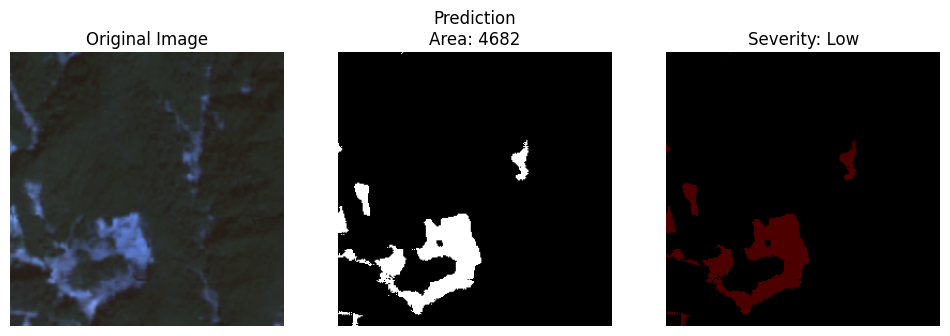

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


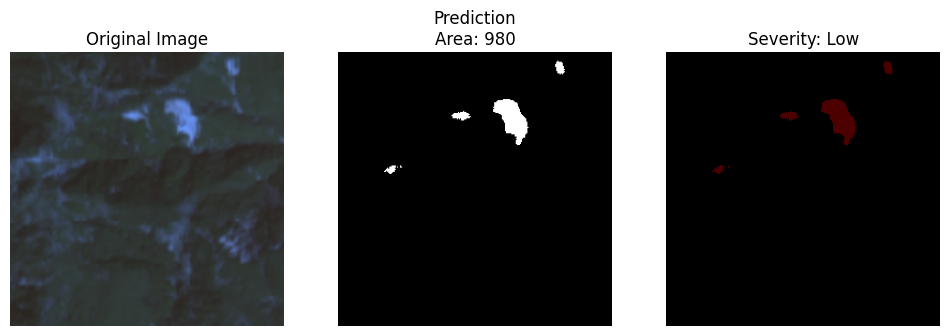

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


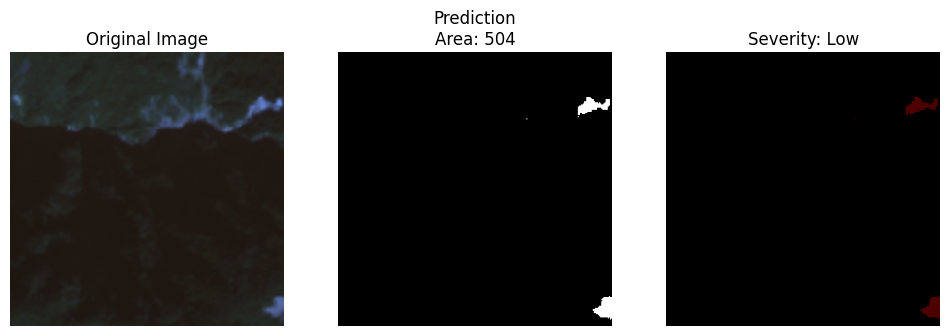

In [16]:
# ================================
# 🔍 Apply on Test Data
# ================================
for i in range(3):   # show 3 samples
    img = read_image(test_images[i])
    mask = read_mask(test_masks[i])

    pred = model.predict(np.expand_dims(img, axis=0))[0]
    pred = (pred > 0.5).astype(np.uint8)

    # Area
    area = calculate_area(pred)

    # Severity
    severity = classify_severity(area)

    # Heatmap
    heatmap = generate_heatmap(img, pred)

    # -------------------------------
    # Display
    # -------------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title(f"Prediction\nArea: {area}")
    plt.imshow(pred.squeeze(), cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"Severity: {severity}")
    plt.imshow(heatmap.astype(np.uint8))
    plt.axis("off")

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


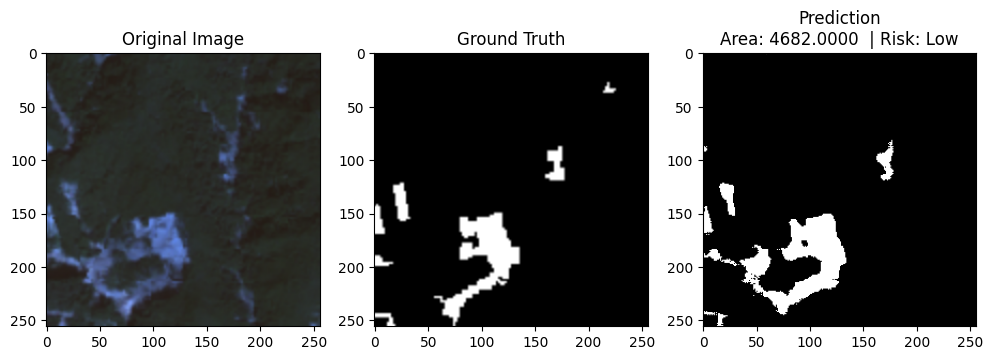

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


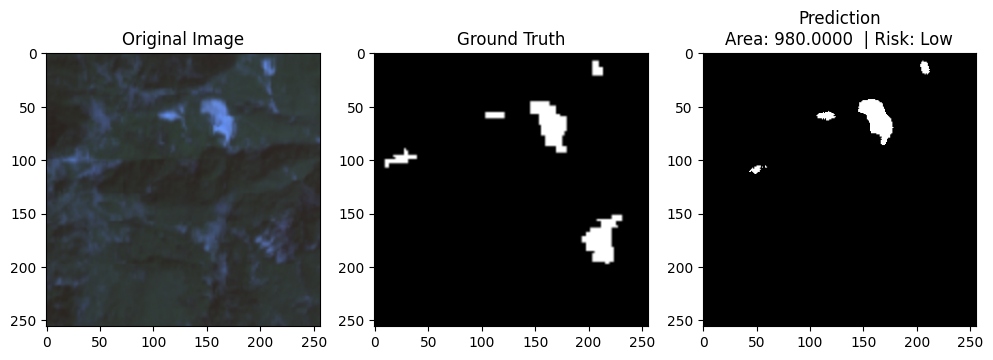

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


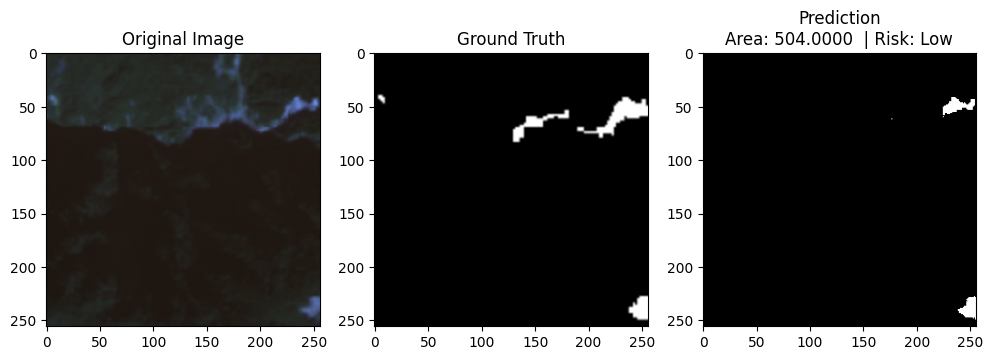

In [18]:
# ================================
# 📊 Step 9: Area Estimation & Risk Classification
# ================================

def calculate_area_and_risk(pred_mask, pixel_resolution=10):
    """
    pred_mask: binary landslide mask (0/1)
    pixel_resolution: meters per pixel (Sentinel-2 = 10m)
    """
    # Count landslide pixels
    landslide_pixels = np.sum(pred_mask)

    # Convert pixels → area (in sq. km)
    area = np.sum(pred_mask)  # m² → km²

    # Risk classification
    if area < 5000:
        risk = "Low"
    elif area < 20000:
        risk = "Medium"
    else:
        risk = "High"

    return area, risk

# Example on test images
for i in range(3):
    image = read_image(test_images[i])
    mask = read_mask(test_masks[i])

    pred = model.predict(np.expand_dims(image, axis=0))[0]
    pred_bin = (pred > 0.5).astype(np.uint8)[:, :, 0]

    # Estimate area & risk
    area, risk = calculate_area_and_risk(pred_bin)

    # Visualization
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(image)

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(mask[:, :, 0], cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title(f"Prediction\nArea: {area:.4f}  | Risk: {risk}")
    plt.imshow(pred_bin, cmap='gray')
    plt.show()
